In [3]:
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import numpy as np


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------- ----------- 5.8/8.2 MB 30.0 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 25.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   -- ------------------------------------- 1.8/36.6 MB 10.5 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/36.6 MB 13.1 MB/s eta 0:00:03
   ------- -------------------------------- 6.8/36.6 MB 11.3 MB/s eta 0:00:03
   ------------ --------------------------- 11.5/36.6 MB 14.7 MB/s eta 0:00:02
   --------------- ------------------------ 13.9/36.6 MB 14.3 MB/s eta 0:00:02
   -------------------- ------------------- 19.1/36.6 MB 15.7 MB/s eta 0:00:02
   --------------------- ------------------ 19.9/36.6 MB 13.6 MB/s eta 0:00:02
   ---------------------- ----------------- 21.0/36.6 MB 12.5 MB/s eta 0:00:02
   ------

In [4]:
# Download the data, if not already on disk and load it as numpy arrays
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

Extract meaningful parameters of the faces dataset.

In [5]:
# introspect the images arrays to find the shapes (for plotting)
n_samples, h, w = lfw_people.images.shape
# for machine learning we use the 2 data directly (as relative pixel
# positions info is ignored by this model)
X = lfw_people.data
n_features = X.shape[1]
# the label to predict is the id of the person
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]
print("Total dataset size:")
print("n_samples: %d" % n_samples)
print("n_features: %d" % n_features)
print("n_classes: %d" % n_classes)

Total dataset size:
n_samples: 1288
n_features: 1850
n_classes: 7


Split data into training and testing sets, also, having a validation set is ideal.

In [6]:
# Split into a training set and a test set using a stratified k fold
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)
# Compute a PCA (eigenfaces) on the face dataset (treated as unlabeled
# dataset): unsupervised feature extraction / dimensionality reduction
n_components = 150

Compute the PCA via eigen-decomposition of the data matrix X after the mean of the training set is removed. This results in a model with variations from the mean. We also transform the training and testing data into ’face space’, i.e. the learned sub space of the eigen-faces.

In [7]:
# Center data
mean = np.mean(X_train, axis=0)
X_train -= mean
X_test -= mean
# Eigen-decomposition
U, S, V = np.linalg.svd(X_train, full_matrices=False)
components = V[:n_components]
eigenfaces = components.reshape((n_components, h, w))
# project into PCA subspace
X_transformed = np.dot(X_train, components.T)
print(X_transformed.shape)
X_test_transformed = np.dot(X_test, components.T)
print(X_test_transformed.shape)

(966, 150)
(322, 150)


Plot resulting eigenvectors of the face PCA model (eigenfaces).

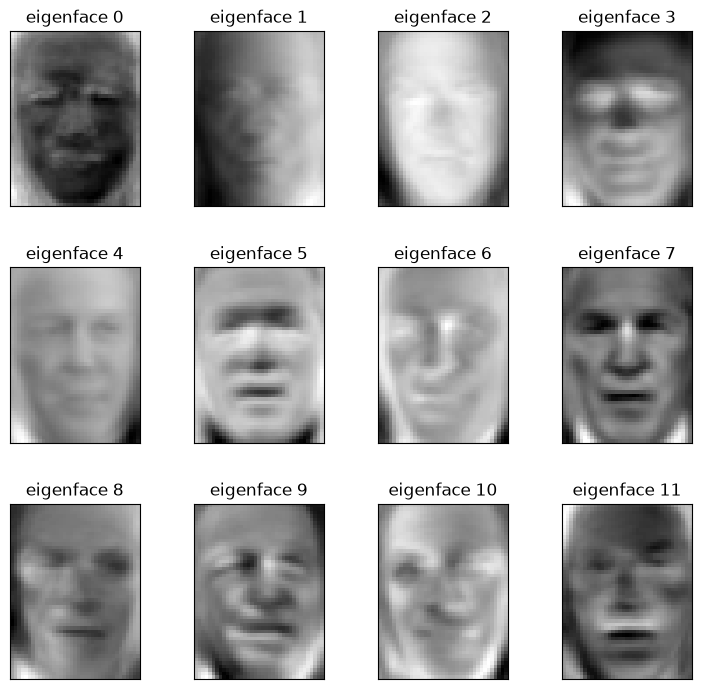

In [8]:
import matplotlib.pyplot as plt


# Qualitative evaluation of the predictions using matplotlib
def plot_gallery(images, titles, h, w, n_row=3, n_col=4):
    """Helper function to plot a gallery of portraits"""
    plt.figure(figsize=(1.8 * n_col, 2.4 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        plt.imshow(images[i].reshape((h, w)), cmap=plt.cm.gray)
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())


eigenface_titles = ["eigenface %d" % i for i in range(eigenfaces.shape[0])]
plot_gallery(eigenfaces, eigenface_titles, h, w)
plt.show()

Evaluate the performance of the dimensionality reduction via compactness plot.

(966,)


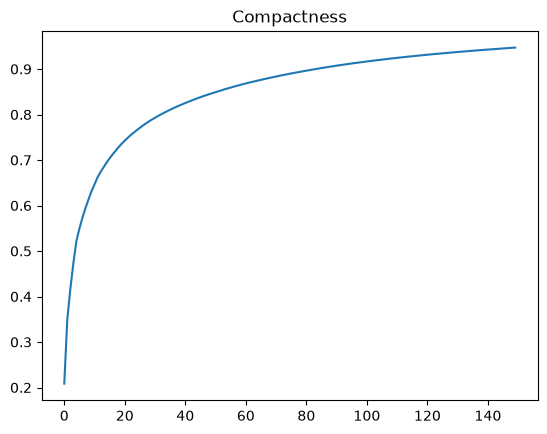

In [9]:
explained_variance = (S ** 2) / (n_samples - 1)
total_var = explained_variance.sum()
explained_variance_ratio = explained_variance / total_var
ratio_cumsum = np.cumsum(explained_variance_ratio)
print(ratio_cumsum.shape)
eigenvalueCount = np.arange(n_components)
plt.plot(eigenvalueCount, ratio_cumsum[:n_components])
plt.title('Compactness')
plt.show()

Use the PCA ’face space’ as features and build a random forest classifier to classify the faces according to the labels. We then view its classification performance.

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
# build random forest
estimator = RandomForestClassifier(n_estimators=150, max_depth=15, max_features=150)
estimator.fit(X_transformed, y_train)  # expects X as [n_samples, n_features]
predictions = estimator.predict(X_test_transformed)
correct = predictions == y_test
total_test = len(X_test_transformed)

# print("Gnd Truth:", y_test)
print("Total Testing", total_test)
print("Predictions", predictions)
print("Which Correct:", correct)
print("Total Correct:", np.sum(correct))
print("Accuracy:", np.sum(correct) / total_test)

Total Testing 322
Predictions [3 3 4 3 3 3 3 1 3 3 3 4 3 3 3 3 4 3 3 4 1 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 1 3 1 3 1 1 3 3 3 4 3 3 3 3 3 1 2 1 3 3 3 6 1 3 4 3 5 3 4 3 3 6 6 3 3
 3 2 3 6 1 3 6 3 3 3 3 3 3 3 3 3 5 6 3 1 1 3 1 1 2 6 3 3 3 3 3 3 3 3 3 1 3
 3 6 3 3 3 1 4 1 3 1 3 3 1 3 4 5 3 1 3 6 6 3 3 3 4 3 3 1 6 3 3 3 1 3 3 3 3
 6 1 1 3 3 3 3 3 6 3 3 3 6 5 5 1 3 3 5 1 3 3 1 3 3 1 5 3 3 2 3 3 3 3 1 3 3
 3 3 3 3 2 5 3 2 3 6 3 3 3 3 3 3 3 3 3 5 1 4 2 6 3 1 3 3 3 4 4 3 1 3 3 3 5
 3 1 1 3 3 3 1 3 3 3 3 3 3 1 3 6 3 3 3 4 3 3 3 3 3 3 3 5 4 4 3 4 3 4 3 1 3
 3 3 3 3 1 3 6 6 1 6 1 1 1 3 3 6 3 3 3 3 3 1 1 3 3 3 3 3 3 3 4 3 3 5 3 3 1
 3 6 3 3 3 6 3 3 1 3 3 3 1 3 3 3 1 3 1 3 3 3 3 3 4 3]
Which Correct: [ True  True False  True  True  True False  True  True  True  True False
  True False  True  True False  True  True  True  True False  True False
 False False False  True  True  True False  True  True  True  True  True
  True  True  True  True  True  True  True  True  True False False  True
 False  T

In [11]:
print(classification_report(y_test, predictions, target_names=target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        13
     Colin Powell       0.68      0.57      0.62        60
  Donald Rumsfeld       0.71      0.19      0.29        27
    George W Bush       0.60      0.87      0.71       146
Gerhard Schroeder       0.50      0.40      0.44        25
      Hugo Chavez       0.50      0.40      0.44        15
       Tony Blair       0.57      0.36      0.44        36

         accuracy                           0.61       322
        macro avg       0.51      0.40      0.42       322
     weighted avg       0.59      0.61      0.57       322



c:\Users\Catherine Aurellia\uni\semester_7\COMP3710\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Catherine Aurellia\uni\semester_7\COMP3710\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Catherine Aurellia\uni\semester_7\COMP3710\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _war